In [29]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error 

import warnings
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv("House_Price.csv")
data.columns

Index(['id', 'Date', 'No of bedrooms', 'No of bathrooms', 'living area',
       'lot area', 'No of floors', 'waterfront present', 'No of views',
       'house condition', 'house grade', 'house area(excluding basement)',
       'Area of the basement', 'Built Year', 'Renovation Year', 'Postal Code',
       'Lattitude', 'Longitude', 'living_area_renov', 'lot_area_renov',
       'No of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')

In [5]:
data.head()

,id,Date,No of bedrooms,No of bathrooms,living area,lot area,No of floors,waterfront present,No of views,house condition,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,No of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


In [9]:
data.shape

(14619, 23)

In [11]:
data.drop_duplicates(inplace=True)

In [13]:
x = data.drop(['id', 'Date', 'Price'], axis = 1)
x

,No of bedrooms,No of bathrooms,living area,lot area,No of floors,waterfront present,No of views,house condition,house grade,house area(excluding basement),Area of the basement,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,No of schools nearby,Distance from the airport
0,4,2.50,2920,4000,1.5,0,0,5,8,1910,1010,1909,0,122004,52.8878,-114.470,2470,4000,2,51
1,5,2.75,2910,9480,1.5,0,0,3,8,2910,0,1939,0,122004,52.8852,-114.468,2940,6600,1,53
2,4,2.50,3310,42998,2.0,0,0,3,9,3310,0,2001,0,122005,52.9532,-114.321,3350,42847,3,76
3,3,2.00,2710,4500,1.5,0,0,4,8,1880,830,1929,0,122006,52.9047,-114.485,2060,4500,1,51
4,3,2.50,2600,4750,1.0,0,0,4,9,1700,900,1951,0,122007,52.9133,-114.590,2380,4750,1,67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14614,2,1.50,1556,20000,1.0,0,0,4,7,1556,0,1957,0,122066,52.6191,-114.472,2250,17286,3,76
14615,3,2.00,1680,7000,1.5,0,0,4,7,1680,0,1968,0,122072,52.5075,-114.393,1540,7480,3,59
14616,2,1.00,1070,6120,1.0,0,0,3,6,1070,0,1962,0,122056,52.7289,-114.507,1130,6120,2,64
14617,4,1.00,1030,6621,1.0,0,0,4,6,1030,0,1955,0,122042,52.7157,-114.411,1420,6631,3,54


In [14]:
y = data['Price']
y

0        1400000
1        1200000
2         838000
3         805000
4         790000
          ...   
14614     221700
14615     219200
14616     209000
14617     205000
14618     146000
Name: Price, Length: 14619, dtype: int64

In [32]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, shuffle=True, 
)

In [33]:
linear_model  = LinearRegression()

In [34]:
linear_model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
linear_model.intercept_

-61854350.390590094

In [20]:
linear_model.coef_

array([-3.12970678e+04,  4.07275867e+04,  1.07674088e+02,  2.41292548e-02,
        2.34831680e+03,  5.68329202e+05,  4.85190062e+04,  3.16856409e+04,
        9.93857668e+04,  7.30114937e+01,  3.46625948e+01, -2.51487268e+03,
        2.65346953e+01,  2.12016914e+02,  5.53806683e+05, -9.57021530e+04,
        2.02258534e+01, -3.59282602e-01,  2.67245623e+03,  8.85240469e+01])

In [35]:
y_pred = linear_model.predict(x_test)
y_pred

array([ 541024.21591061,  495020.53871031,  543009.84805658, ...,
        779322.25214279,  540825.15223153, 1865627.59266099])

In [36]:
error = y_test - y_pred
error

7983       5775.784089
6466      54979.461290
10306   -143059.848057
1217     118499.147226
12463   -190227.062348
             ...      
2264     -27446.312236
8361     -22863.008949
3975     -84322.252143
10216    -92825.152232
9726     664372.407339
Name: Price, Length: 2924, dtype: float64

In [28]:
print(y_test[:5])
print(y_pred[:5])

7983     546800
6466     550000
10306    399950
1217     940000
12463    545000
Name: Price, dtype: int64
[541024.21591061 495020.53871031 543009.84805658 821500.85277404
 735227.06234816]


In [ ]:
accuracy = r2_score(y_test, y_pred)
accuracy

0.7019556493273452

In [38]:
MAE = mean_absolute_error(y_test, y_pred)
MAE

125379.66463287694

In [39]:
MSE = mean_squared_error(y_test, y_pred)
MSE

44109393059.22732

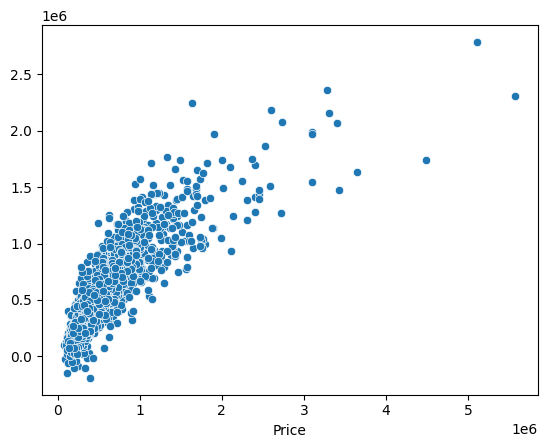

In [23]:
sns.scatterplot(x = y_test, y = y_pred)
plt.show()